# Take-or-Pay Gas Contract Optimization

**Goal:** minimize 24-month gas supply cost across a TOP contract, spot market and
storage — with make-up banking modeled properly.

**Technique highlights**
* Multi-period LP with two inventory states (storage + make-up bank)
* Minimum-bill linearization of the take-or-pay clause
* Value decomposition: what do storage and make-up rights each contribute?

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pulp

PALETTE = ["#2a78d6", "#1baf7a", "#eda100", "#008300", "#4a3aa7", "#e34948", "#e87ba4", "#eb6834"]
plt.rcParams.update({
    "axes.prop_cycle": plt.cycler(color=PALETTE), "axes.grid": True,
    "grid.color": "#e1e0d9", "axes.edgecolor": "#c3c2b7",
    "axes.spines.top": False, "axes.spines.right": False,
    "figure.facecolor": "white", "axes.facecolor": "#fcfcfb",
})
rng = np.random.default_rng(42)

## 1. Inputs: demand, prices, contract terms

In [2]:
T = 24
months = np.arange(T)
demand = 900 + 350 * np.cos(2 * np.pi * (months - 1) / 12) + rng.normal(0, 40, T)
spot = 7.0 + 2.8 * np.cos(2 * np.pi * (months - 1) / 12) + rng.normal(0, 0.5, T)

ACQ, TOP_FRAC, P_CONTRACT = 800.0, 0.85, 6.2          # TJ/mo, min-bill fraction, $/GJ
MAKEUP_EXPIRY_MO = 12
STOR_CAP, STOR_RATE, STOR_COST = 1_500.0, 400.0, 0.35  # TJ, TJ/mo, $/GJ cycled

df = pd.DataFrame({"month": months, "demand_tj": demand.round(0),
                   "spot_price": spot.round(2)})
df.to_csv("gas_portfolio_inputs.csv", index=False)

## 2. Linear program

In [3]:
def solve(spot_prices, use_storage=True, use_makeup=True):
    m = pulp.LpProblem("gas_portfolio", pulp.LpMinimize)
    lift = pulp.LpVariable.dicts("lift", months, 0, ACQ)          # contract liftings
    spot_buy = pulp.LpVariable.dicts("spot", months, 0)
    bill = pulp.LpVariable.dicts("bill", months, 0)               # billed contract qty
    makeup_use = pulp.LpVariable.dicts("mk_use", months, 0)
    bank = pulp.LpVariable.dicts("bank", months, 0)               # make-up bank level
    inj = pulp.LpVariable.dicts("inj", months, 0, STOR_RATE if use_storage else 0)
    wdr = pulp.LpVariable.dicts("wdr", months, 0, STOR_RATE if use_storage else 0)
    stor = pulp.LpVariable.dicts("stor", months, 0, STOR_CAP)

    m += pulp.lpSum(bill[t] * P_CONTRACT + spot_buy[t] * spot_prices[t]
                    + (inj[t] + wdr[t]) * STOR_COST for t in months)
    for t in months:
        # demand balance: contract + makeup + spot + net storage
        m += (lift[t] + makeup_use[t] + spot_buy[t] + wdr[t] - inj[t]
              == demand[t])
        # minimum bill: pay at least TOP fraction
        m += bill[t] >= lift[t]
        m += bill[t] >= TOP_FRAC * ACQ
        # make-up bank: paid-not-taken accumulates, usage draws down
        prev_bank = bank[t - 1] if t > 0 else 0
        m += bank[t] == prev_bank + (bill[t] - lift[t]) - makeup_use[t]
        if not use_makeup:
            m += makeup_use[t] == 0
        # crude expiry: bank capped at expiry-window of shortfalls
        m += bank[t] <= TOP_FRAC * ACQ * MAKEUP_EXPIRY_MO * 0.15
        # storage balance
        prev_stor = stor[t - 1] if t > 0 else STOR_CAP * 0.3
        m += stor[t] == prev_stor + inj[t] - wdr[t]
    m.solve(pulp.PULP_CBC_CMD(msg=0))
    out = pd.DataFrame({
        "month": months,
        "lift": [lift[t].value() for t in months],
        "makeup_use": [makeup_use[t].value() for t in months],
        "spot": [spot_buy[t].value() for t in months],
        "withdraw": [wdr[t].value() for t in months],
        "inject": [inj[t].value() for t in months],
        "storage": [stor[t].value() for t in months],
        "bank": [bank[t].value() for t in months],
    })
    return out, pulp.value(m.objective)

plan, cost = solve(spot)
_, cost_nostor = solve(spot, use_storage=False)
_, cost_nomk = solve(spot, use_makeup=False)
print(f"Optimized 24-mo cost: ${cost/1e3:,.1f}MM")
print(f"Storage value: ${(cost_nostor - cost)/1e3:,.1f}MM   "
      f"Make-up rights value: ${(cost_nomk - cost)/1e3:,.1f}MM")

Optimized 24-mo cost: $127.2MM
Storage value: $3.9MM   Make-up rights value: $7.7MM


## 3. Dispatch picture

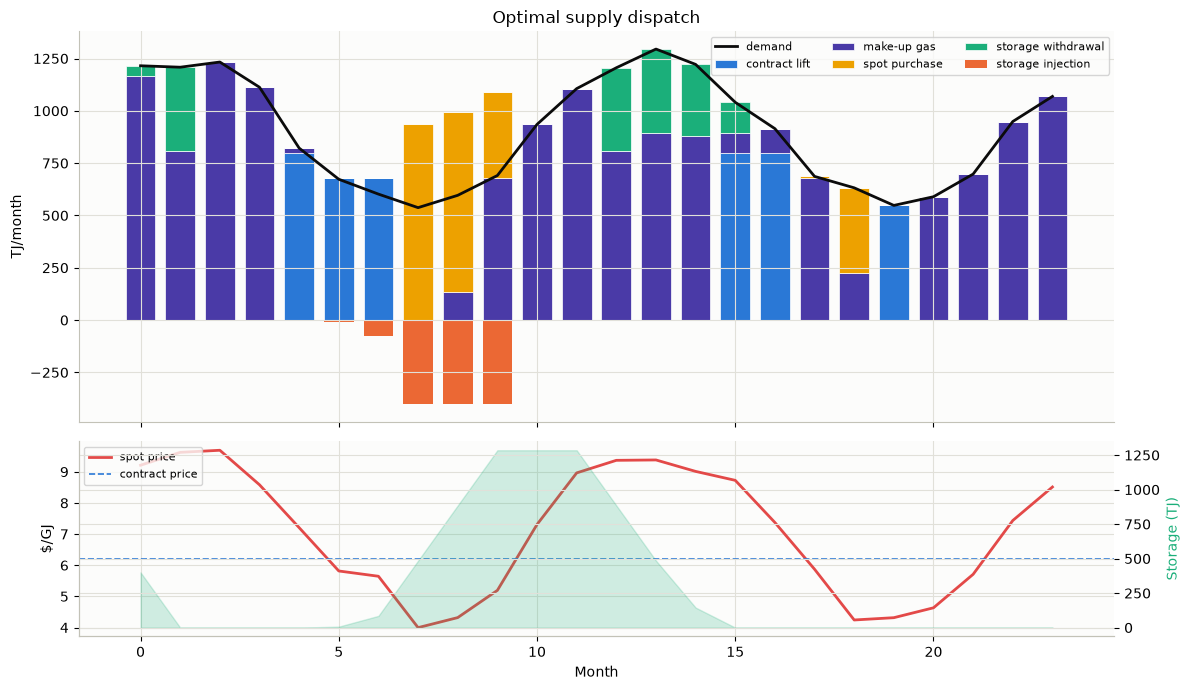

In [4]:
fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True,
                         gridspec_kw={"height_ratios": [2, 1]})
bottom = np.zeros(T)
for col, color, label in [("lift", PALETTE[0], "contract lift"),
                          ("makeup_use", PALETTE[4], "make-up gas"),
                          ("spot", PALETTE[2], "spot purchase"),
                          ("withdraw", PALETTE[1], "storage withdrawal")]:
    axes[0].bar(months, plan[col], bottom=bottom, color=color, label=label,
                width=0.75, edgecolor="white", linewidth=0.5)
    bottom += plan[col].values
axes[0].bar(months, -plan.inject, color=PALETTE[7], label="storage injection",
            width=0.75)
axes[0].plot(months, demand, lw=2, color="#0b0b0b", label="demand")
axes[0].set(ylabel="TJ/month", title="Optimal supply dispatch")
axes[0].legend(ncol=3, fontsize=8)

ax2 = axes[1]
ax2.plot(months, spot, lw=2, color=PALETTE[5], label="spot price")
ax2.axhline(P_CONTRACT, ls="--", lw=1.2, color=PALETTE[0], label="contract price")
ax2b = ax2.twinx()
ax2b.fill_between(months, plan.storage, color=PALETTE[1], alpha=0.2)
ax2b.set_ylabel("Storage (TJ)", color=PALETTE[1])
ax2.set(xlabel="Month", ylabel="$/GJ")
ax2.legend(fontsize=8, loc="upper left")
plt.tight_layout()
plt.show()

## 4. Sensitivity: what if spot runs hotter?

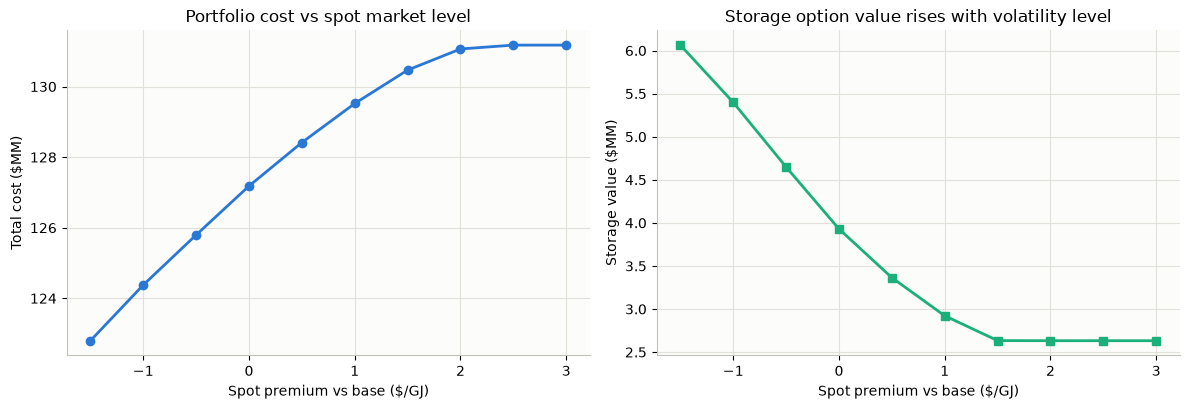

In [5]:
premiums = np.linspace(-1.5, 3.0, 10)
costs = [solve(spot + p)[1] / 1e3 for p in premiums]
values_stor = [(solve(spot + p, use_storage=False)[1] - solve(spot + p)[1]) / 1e3
               for p in premiums]

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
axes[0].plot(premiums, costs, marker="o", lw=2, color=PALETTE[0])
axes[0].set(xlabel="Spot premium vs base ($/GJ)", ylabel="Total cost ($MM)",
            title="Portfolio cost vs spot market level")
axes[1].plot(premiums, values_stor, marker="s", lw=2, color=PALETTE[1])
axes[1].set(xlabel="Spot premium vs base ($/GJ)", ylabel="Storage value ($MM)",
            title="Storage option value rises with volatility level")
plt.tight_layout()
plt.show()

## Conclusions

* The optimizer lifts at minimum bill through cheap-spot summers (banking make-up
  rights), then burns the bank and storage through the winter premium — textbook
  contract arbitrage, discovered by the LP rather than encoded by rules.
* Decomposition prices each flexibility separately: storage and make-up rights are
  each worth millions over 24 months — numbers that belong in contract renegotiations.
* The LP structure (two coupled inventories + minimum-bill linearization) is the
  reusable pattern for most energy contract-portfolio problems.
* **Next step:** stochastic prices (scenario LP) to value flexibility properly as an
  option, and daily granularity with swing limits.